In [16]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

df = pd.read_csv('data/all_players.csv')
print(df.shape)
df.head()

(3121, 42)


,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,Gls_p90,Ast_p90,G+A_p90,G-PK_p90,G+A-PK_p90,league,team_Gls,team_Ast,pct_of_team_goals,pct_of_team_assists,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,team_TklW,team_Int,pct_of_team_tackles,pct_of_team_interceptions
0,1,James Abankwah,ie IRL,DF,Watford,21.0,2004.0,31,30,2596,28.8,1,0,1,1,0,0,5,1,0.03,0.00,0.03,0.03,0.03,Championship,52,34,1.9,0.0,40,28,3,14,29,29,NaN,NaN,0,444,401,6.5,7.2
1,2,Ebou Adams,gm GAM,MF,Derby County,29.0,1996.0,23,16,1506,16.7,1,0,1,1,0,0,7,0,0.06,0.00,0.06,0.06,0.06,Championship,64,43,1.6,0.0,36,37,4,10,25,38,NaN,NaN,0,428,429,8.9,5.8
2,3,Ebou Adams,gm GAM,MF,Portsmouth,29.0,1996.0,16,14,1234,13.7,2,1,3,2,0,0,3,0,0.15,0.07,0.22,0.15,0.22,Championship,47,29,4.3,3.4,20,41,0,10,13,28,NaN,NaN,0,393,379,7.1,3.4
3,4,Kealey Adamson,au AUS,DF,QPR,22.0,2003.0,7,1,223,2.5,0,0,0,0,0,0,1,0,0.00,0.00,0.00,0.00,0.00,Championship,55,35,0.0,0.0,5,1,0,3,1,4,NaN,NaN,0,437,359,0.9,0.3
4,5,Tayo Adaramola,ie IRL,"MF,DF",Sheffield Weds,21.0,2003.0,16,15,1328,14.8,0,1,1,0,0,0,2,0,0.00,0.07,0.07,0.00,0.07,Championship,29,15,0.0,6.7,11,20,0,33,7,27,NaN,NaN,0,469,454,5.8,1.5


In [17]:
df.columns.tolist()

['Rk',
 'Player',
 'Nation',
 'Pos',
 'Squad',
 'Age',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'Gls_p90',
 'Ast_p90',
 'G+A_p90',
 'G-PK_p90',
 'G+A-PK_p90',
 'league',
 'team_Gls',
 'team_Ast',
 'pct_of_team_goals',
 'pct_of_team_assists',
 'Fls',
 'Fld',
 'Off',
 'Crs',
 'Int',
 'TklW',
 'PKwon',
 'PKcon',
 'OG',
 'team_TklW',
 'team_Int',
 'pct_of_team_tackles',
 'pct_of_team_interceptions']

In [18]:
df['league'].value_counts()

league
Championship      791
Serie B           638
Brazil Serie B    595
2. Bundesliga     553
Ligue 2           544
Name: count, dtype: int64

In [19]:
df[['Age', 'Gls', 'Ast', 'Min', 'pct_of_team_goals']].describe()

,Age,Gls,Ast,Min,pct_of_team_goals
count,3101.000000,3121.000000,3121.000000,3121.000000,3121.000000
mean,25.227668,1.386735,0.950016,1080.599808,3.211823
std,4.687914,2.579518,1.618622,956.171146,5.762416
min,15.000000,0.000000,0.000000,1.000000,0.000000
25%,21.000000,0.000000,0.000000,275.000000,0.000000
50%,25.000000,0.000000,0.000000,820.000000,0.000000
75%,28.000000,2.000000,1.000000,1682.000000,4.300000
max,40.000000,24.000000,15.000000,4140.000000,50.000000


## Top Scorers Overall

In [20]:
MIN_MINUTES = 900

qualified = df[df['Min'] >= MIN_MINUTES].copy()

top_scorers = qualified.sort_values('Gls_p90', ascending=False).reset_index(drop=True)
top_scorers.index = top_scorers.index + 1

top_scorers[['Player', 'Squad', 'league', 'Age', 'Gls', 'Gls_p90', 'Ast', 'Min']].head(20)

,Player,Squad,league,Age,Gls,Gls_p90,Ast,Min
1,Ivan Prtajin,Kaiserslautern,2. Bundesliga,29.0,11,0.96,1,1030
2,Younes Ebnoutalib,Elversberg,2. Bundesliga,21.0,12,0.86,0,1260
3,Mateusz Żukowski,Magdeburg,2. Bundesliga,23.0,17,0.83,3,1838
4,Tawfik Bentayeb,Troyes,Ligue 2,23.0,18,0.83,3,1950
5,Mikael,CRB,Brazil Serie B,27.0,10,0.79,2,1143
6,Filip Bilbija,Paderborn 07,2. Bundesliga,25.0,15,0.75,3,1812
7,Gustavo Coutinho,Atl. Goianiense,Brazil Serie B,27.0,8,0.74,0,967
8,Ross Stewart,Southampton,Championship,29.0,8,0.73,2,981
9,Andrea Adorante,Venezia,Serie B,25.0,17,0.72,1,2132
10,Andrea Petagna,Monza,Serie B,30.0,9,0.72,2,1120


## Highest % of Team Overall Goals

In [21]:
MIN_MINUTES = 900  # roughly 10 full matches - adjust as you like

qualified = df[df['Min'] >= MIN_MINUTES]
qualified.sort_values('pct_of_team_goals', ascending=False)[
    ['Player', 'Squad', 'league', 'Age', 'Gls', 'team_Gls', 'pct_of_team_goals']
].head(20)

,Player,Squad,league,Age,Gls,team_Gls,pct_of_team_goals
3024,Bruno Santos,Londrina,Brazil Serie B,29.0,11,22,50.0
998,Cedric Itten,Düsseldorf,2. Bundesliga,28.0,15,31,48.4
2638,Gustavo Coutinho,Atl. Goianiense,Brazil Serie B,27.0,8,18,44.4
2887,Mikael,CRB,Brazil Serie B,27.0,10,24,41.7
2387,Joel Pohjanpalo,Palermo,Serie B,30.0,24,58,41.4
744,Žan Vipotnik,Swansea City,Championship,23.0,23,56,41.1
929,Noel Futkeu,Greuther Fürth,2. Bundesliga,22.0,19,48,39.6
2574,Chrystian Barletta,Sport Recife,Brazil Serie B,25.0,8,21,38.1
2586,Gabriel Boschilia,Operário,Brazil Serie B,30.0,7,19,36.8
1658,Louis Mafouta,Guingamp,Ligue 2,31.0,15,42,35.7


## Age Distribution 

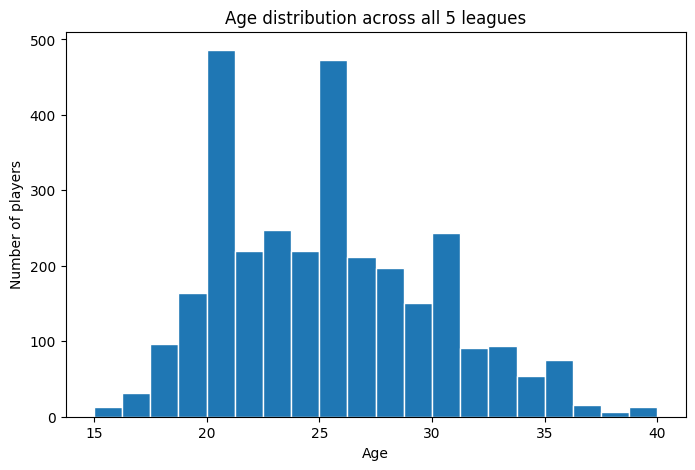

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df['Age'].dropna(), bins=20, edgecolor='white')
plt.xlabel('Age')
plt.ylabel('Number of players')
plt.title('Age distribution across all 5 leagues')
plt.show()

## Young players with impact

In [24]:
MAX_AGE = 23
MIN_PCT_TEAM_GOALS = 20

young_impact = df[
    (df['Age'] <= MAX_AGE) &
    (df['Min'] >= MIN_MINUTES) &
    (df['pct_of_team_goals'] >= MIN_PCT_TEAM_GOALS)
]

young_impact_ranked = young_impact.sort_values('pct_of_team_goals', ascending=False).reset_index(drop=True)
young_impact_ranked.index = young_impact_ranked.index + 1

young_impact_ranked[['Player', 'Squad', 'league', 'Age', 'Gls', 'pct_of_team_goals']]

,Player,Squad,league,Age,Gls,pct_of_team_goals
1,Žan Vipotnik,Swansea City,Championship,23.0,23,41.1
2,Noel Futkeu,Greuther Fürth,2. Bundesliga,22.0,19,39.6
3,Mateusz Żukowski,Magdeburg,2. Bundesliga,23.0,17,34.7
4,Steven Shpendi,Empoli,Serie B,22.0,15,31.9
5,Gabriele Artistico,Spezia,Serie B,23.0,13,31.0
6,Mohamed Zoma,Nürnberg,2. Bundesliga,21.0,14,30.4
7,Tawfik Bentayeb,Troyes,Ligue 2,23.0,18,30.0
8,Taïryk Arconte,Rodez AF,Ligue 2,21.0,13,28.9
9,Cristian Shpendi,Cesena,Serie B,22.0,12,27.9
10,Melk,Ceará,Brazil Serie B,19.0,4,26.7


## Team reliance vs Raw goal volume / 90 minutes

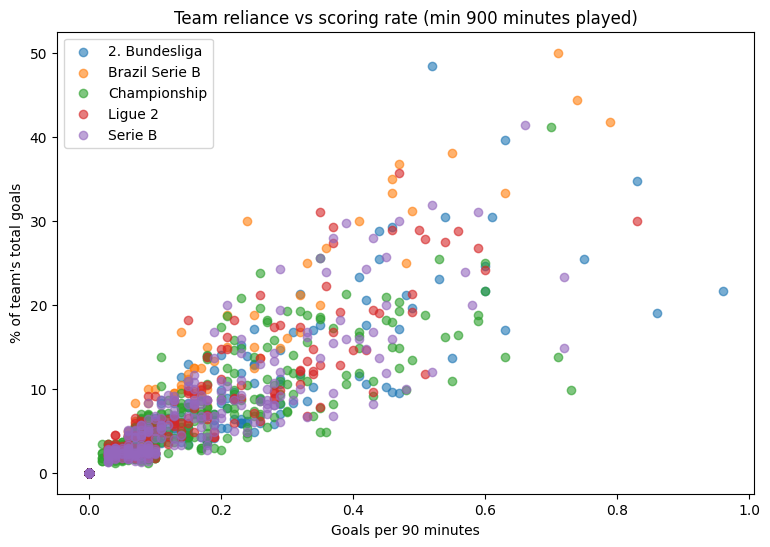

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))

for league_name, group in df[df['Min'] >= MIN_MINUTES].groupby('league'):
    ax.scatter(group['Gls_p90'], group['pct_of_team_goals'], label=league_name, alpha=0.6)

ax.set_xlabel('Goals per 90 minutes')
ax.set_ylabel('% of team\'s total goals')
ax.set_title('Team reliance vs scoring rate (min 900 minutes played)')
ax.legend()
plt.show()

## Big Impact Subs

In [25]:
df['sub_appearances'] = df['MP'] - df['Starts']
df['goals_per_start'] = (df['Gls'] / df['Starts'].replace(0, pd.NA)).round(2)

supersubs = df[
    (df['sub_appearances'] >= 5) &
    (df['Starts'] < df['sub_appearances'] * 0.5) &  # genuinely sub-heavy, not just borderline
    (df['G+A'] >= 7)  # raised from 5, so it's a shorter, more meaningful list
]

supersubs_ranked = supersubs.sort_values('G+A', ascending=False).reset_index(drop=True)
supersubs_ranked.index = supersubs_ranked.index + 1

supersubs_ranked[['Player', 'Squad', 'league', 'Age', 'MP', 'Starts', 'sub_appearances', 'G+A']]

,Player,Squad,league,Age,MP,Starts,sub_appearances,G+A
1,Josh Duffus,Saint-Étienne,Ligue 2,20.0,27,7,20,10
2,Adam Idah,Swansea City,Championship,24.0,25,6,19,8
3,Luca Schnellbacher,Elversberg,2. Bundesliga,31.0,28,7,21,7
4,Lorenzo Meazzi,Pescara,Serie B,24.0,30,8,22,7
5,Raffaele Russo,Avellino,Serie B,26.0,34,9,25,7
6,Juninho,Novorizontino,Brazil Serie B,25.0,16,3,13,7
